Computation Time using Pandas (Serial Processing):
Pandas time: 3.90 seconds

Computation Time using Dask (Parallel Processing):
Dask time: 2.33 seconds


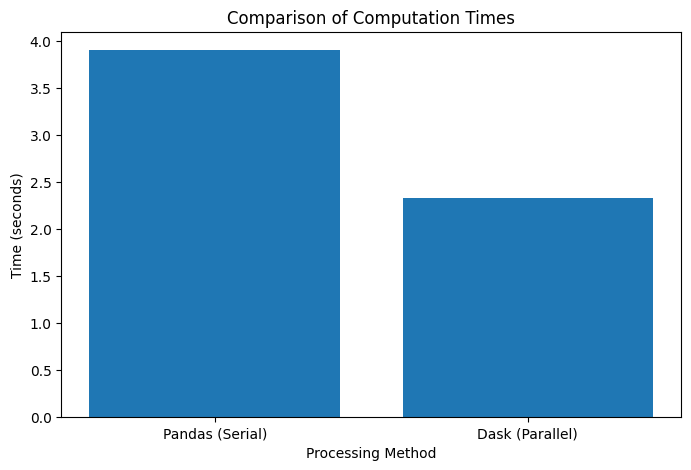

In [2]:
import time
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt

file_path = "Trips_by_Distance.csv"

# pandas serial processing
start_pd = time.time()
df_pd = pd.read_csv(file_path)
result_pd = df_pd.groupby("Week")["Population Staying at Home"].mean()
end_pd = time.time()
pandas_time = end_pd - start_pd

print("Computation Time using Pandas (Serial Processing):")
print(f"Pandas time: {pandas_time:.2f} seconds")

# dask parallel-style processing
start_dask = time.time()
df_dask = dd.read_csv(
    file_path,
    assume_missing=True,
    dtype={
        "County Name": "object",
        "State Postal Code": "object"
    }
)

df_dask["Population Staying at Home"] = df_dask["Population Staying at Home"].fillna(
    df_dask["Population Staying at Home"].mean()
)

result_dask = df_dask.groupby("Week")["Population Staying at Home"].mean().compute()
end_dask = time.time()
dask_time = end_dask - start_dask

print("\nComputation Time using Dask (Parallel Processing):")
print(f"Dask time: {dask_time:.2f} seconds")

# plot comparison
methods = ["Pandas (Serial)", "Dask (Parallel)"]
times = [pandas_time, dask_time]

plt.figure(figsize=(8, 5))
plt.bar(methods, times)
plt.xlabel("Processing Method")
plt.ylabel("Time (seconds)")
plt.title("Comparison of Computation Times")
plt.show()